In [12]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [13]:
import sys

sys.path.append('../scripts')

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import glob
import json

In [15]:
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

In [ ]:
corr_dir = "/data2/a330d/datasets/crc/correlations"
pattern = os.path.join(corr_dir, "crc_*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    if not name.startswith("crc_") or not name.endswith(".json"):
        continue
    core = name[len("crc_"):-len(".json")]
    parts = core.split("_")
    if len(parts) < 3:
        # unexpected filename, skip
        continue
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision@200"),# or data.get("precision@50"),
            "edistance_cells": data.get("edistance_cells"),
            "edistance_latents": data.get("edistance_latents"),
            "edistance_local": data.get("edistance_local"),
            "mixing_index": data.get("mixing_index"),
            "direction_match": data.get("direction_match@200"),
            "rmse": data.get("rmse"),
            "rmse_log1p": data.get("rmse_log1p"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

columns = ["sid", 
           "model_name", 
           "holdout_celltype", 
           "spearman", 
           "pearson", 
           "precision", 
           "edistance_cells", 
           "edistance_latents", 
           "edistance_local", 
           "mixing_index",
           "direction_match",
           "rmse",
           "rmse_log1p"]
crc_corr_df = pd.DataFrame(rows, columns=columns)

In [11]:
keep_rows = ['cf']
# Match substring from above and keep those rows
crc_corr_df = crc_corr_df[crc_corr_df['model_name'].str.contains('|'.join(keep_rows))]
# Remove rows which contain 'recon' substring
discard_models = ['recon', 'mmd']
crc_corr_df = crc_corr_df[~crc_corr_df['model_name'].str.contains('|'.join(discard_models))]
# Remove B cell results - Reason: Missing in two slides
discard_celltypes = ['B_cell']
crc_corr_df = crc_corr_df[~crc_corr_df['holdout_celltype'].isin(discard_celltypes)]
# Remove rows of sid 110, 222 - Reason: 110 has very low correlations for all models, 222 does not have CRC
discard_slides = ['110', '222']
crc_corr_df = crc_corr_df[~crc_corr_df['sid'].isin(discard_slides)]

In [7]:
# Load mintflow results
df = crc_corr_df.copy() # start with existing dataframe
mintflow_base_path = "/data/a330d/projects/cellina-reproducibility/results/mintflow_crc"
mintflow_model_name = "mintflow-normalized"
load_sids_mintflow = ['231', '210', '242', '232', '221']
for i in load_sids_mintflow:
    mintflow_df = pd.read_csv(f"{mintflow_base_path}/{mintflow_model_name}_{i}_by_celltype_correlations.csv")
    df = pd.concat([df, mintflow_df], ignore_index=True)

In [8]:
# Convert sid column to string
df["sid"] = df["sid"].astype(str)

In [9]:
# Apply factor of 0.1 to edistance local
#df["edistance_local"] = df["edistance_local"] * 0.03

In [10]:
model_rename = {
    #"cellina": "cellina",
    #"cellina-cf-recon": "cellina-recon",
    "cellina-cf": "cellina",
    "cpa-cf": "cpa",
    "baseline-cf": "baseline",
    "scgen-cf": "scgen",
    "cellina-ablated-cf": "cellina-ablated",
   # "cellina-mmd-cf": "cellina-mmd",
    "cellina-graph-cf": "cellina-graph",
    mintflow_model_name: "mintflow"
}

# Rename
df.loc[:, "model_name"] = df["model_name"].map(model_rename)

In [40]:
#metrics = ["pearson", "spearman", "precision"]
#metrics = ["pearson", "spearman", "precision", "mixing_index"]
metrics = ["edistance_cells", "edistance_local"]
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    "mintflow",
    "cpa",
    "scgen",
    "cellina-ablated",
    #"cellina-mmd",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [41]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[0]
palette_dict["cellina-mmd"]     = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
#palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]

palette = palette_dict

In [13]:
rank_results = []

N = df["model_name"].nunique()

for metric in metrics:
    tmp = df.copy()

    # 1. Rank within (cell type, sid)
    tmp["rank"] = tmp.groupby(["holdout_celltype", "sid"])[metric] \
                     .rank(ascending=False)

    # 2. Normalize rank to [0, 1]
    tmp["norm_rank"] = 1 - (tmp["rank"] - 1) / (N - 1)

    # 3. Average across sids (per model, per cell type)
    tmp2 = (
        tmp.groupby(["model_name", "holdout_celltype"])["norm_rank"]
        .mean()
        .reset_index()
    )

    # 4. Average across cell types
    agg = (
        tmp2.groupby("model_name")["norm_rank"]
        .agg(["mean", "sem"])
        .reset_index()
    )

    agg["metric"] = metric
    rank_results.append(agg)

rank_df = pd.concat(rank_results, ignore_index=True)

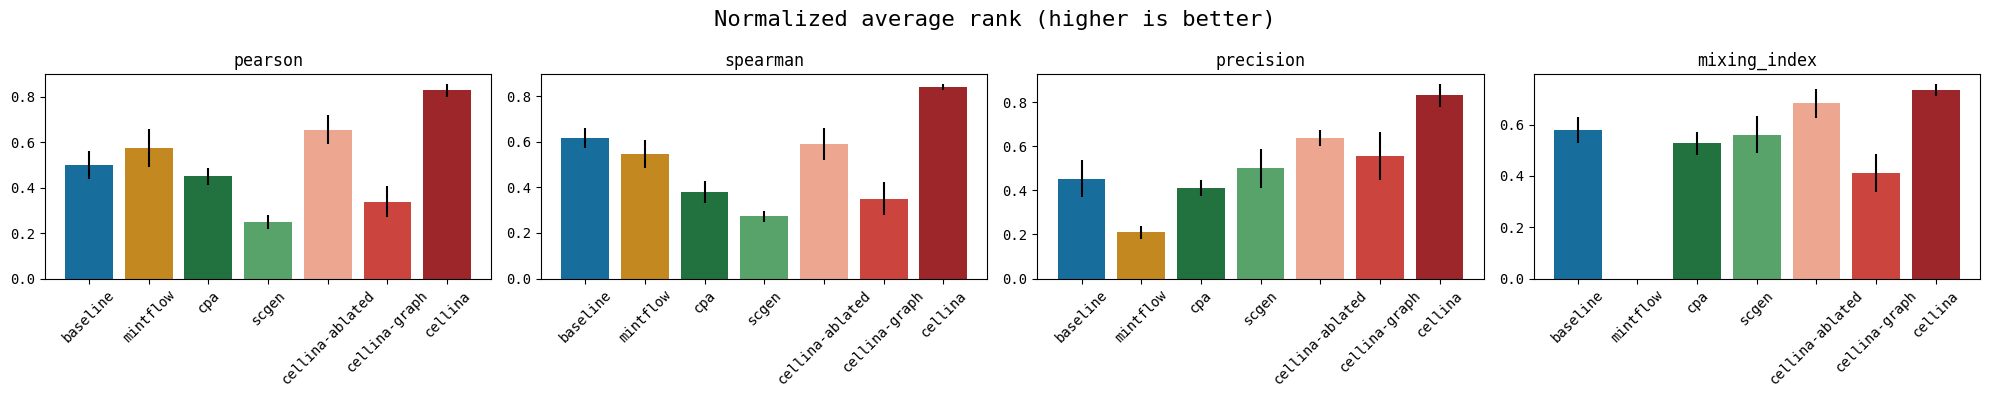

In [14]:
fig, axes = plt.subplots(1, len(metrics), figsize=(5*len(metrics), 4))
fig.suptitle('Normalized average rank (higher is better)', fontsize=16)

if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    sub = rank_df[rank_df.metric == metric]

    sns.barplot(
        data=sub,
        x="model_name",
        y="mean",
        hue="model_name",
        order=model_order,
        palette=palette,
        errorbar=None,  # we add manually
        ax=ax
    )

    # Add SE bars
    for i, model in enumerate(model_order):
        row = sub[sub.model_name == model].iloc[0]
        ax.errorbar(
            x=i,
            y=row["mean"],
            yerr=row["sem"],
            fmt="none",
            capsize=0,
            color="black",
        )

    ax.set_title(f"{metric}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [22]:
def plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    title="Performance (observed vs predicted) for DEG 200",
    save=False,
    save_path="../figures",
    save_name="ood_summary"
):
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Compute global y-limits
    ymin = df[metrics].min().min() * 0.3
    ymax = df[metrics].max().max() * 1.05

    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))
    fig.suptitle(title, fontsize=16)

    # Ensure axes iterable if only one metric
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):

        if not average_only:
            # -------------------------------
            # Per-celltype plot
            # -------------------------------
            celltypes = df[grouping].unique().tolist()
            all_x_labels = list(celltypes) + ["Average"]

            sns.barplot(
                data=df,
                x=grouping,
                y=metric,
                hue="model_name",
                estimator="mean",
                errorbar="se",
                hue_order=model_order,
                ax=ax,
                palette=palette,
                order=celltypes,
            )
            ax.legend_.remove()

            # -------------------------------
            # Add averages manually (WITH SE)
            # -------------------------------
            df_avg = df.groupby("model_name")[metric].mean()
            df_se = df.groupby("model_name")[metric].sem()

            n_models = len(model_order)
            bar_width = 0.8 / n_models

            for i, model in enumerate(model_order):
                avg_val = df_avg.loc[model]
                se_val = df_se.loc[model]

                x_pos = len(celltypes) - 0.4 + i * bar_width + bar_width / 2

                ax.bar(
                    x=x_pos,
                    height=avg_val,
                    width=bar_width,
                    color=palette[model],
                    alpha=0.9,
                    yerr=se_val,
                    capsize=0,
                )

            ax.set_xticks(range(len(all_x_labels)))
            ax.set_xticklabels(all_x_labels, rotation=45)

        else:
            # -------------------------------
            # AVERAGE-ONLY plot (clean)
            # -------------------------------
            df_avg = (
                df.groupby(["model_name"])[metric]
                .agg(["mean", "sem"])
                .reset_index()
            )

            sns.barplot(
                data=df_avg,
                x="model_name",
                y="mean",
                hue="model_name",
                order=model_order,
                palette=palette,
                errorbar=None,  # we add manually
                ax=ax,
            )

            # Add SE manually
            for i, model in enumerate(model_order):
                row = df_avg[df_avg.model_name == model].iloc[0]
                ax.errorbar(
                    x=i,
                    y=row["mean"],
                    yerr=row["sem"],
                    fmt="none",
                    capsize=0,
                    color="black",
                )

            #ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
            ax.tick_params(axis="x", rotation=45)

        # -------------------------------
        # Shared styling
        # -------------------------------
        ax.set_ylim(ymin, ymax)
        ax.set_title(metric)
        ax.set_xlabel("")
        ax.set_ylabel("")

    # -------------------------------
    # Global legend (only once)
    # -------------------------------
    if not average_only:
        handles, labels = axes[0].get_legend_handles_labels()
    else:
        handles = [
            plt.Rectangle((0, 0), 1, 1, color=palette[m])
            for m in model_order
        ]
        labels = model_order

    fig.legend(
        handles,
        labels,
        ncol=len(labels),
        fontsize=10,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.02),
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.3)

    if save:
        plt.savefig(f"{save_path}/{save_name}.svg", format="svg", bbox_inches="tight")
    plt.show()

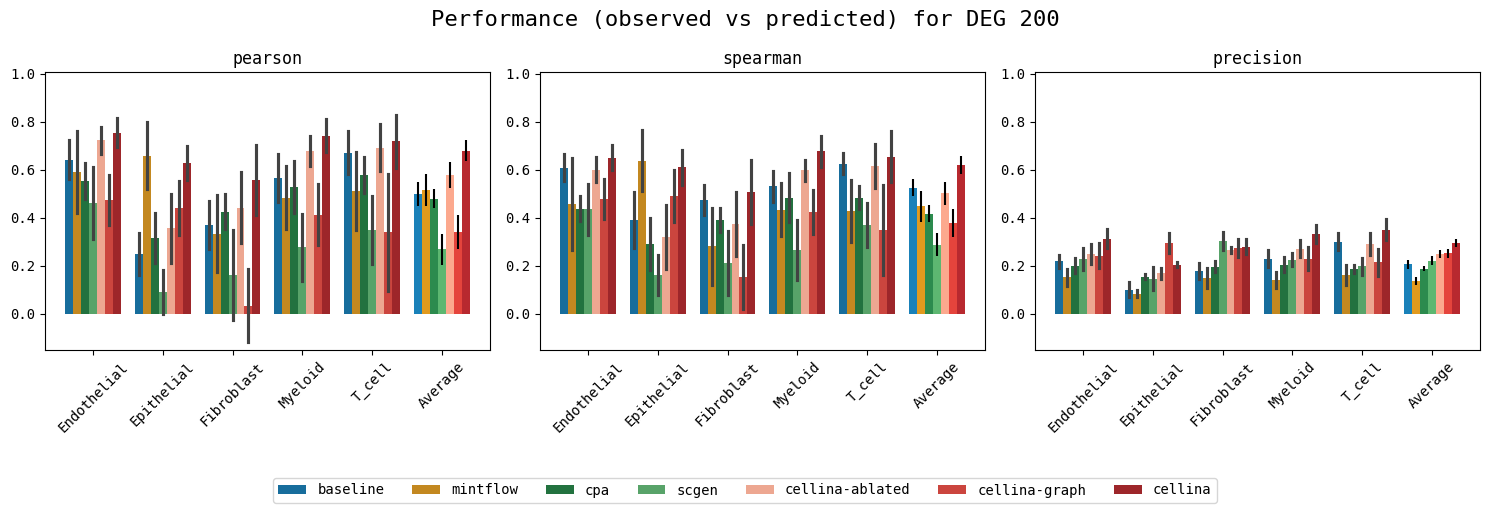

In [38]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name="ood_summary_correlations_200"
)

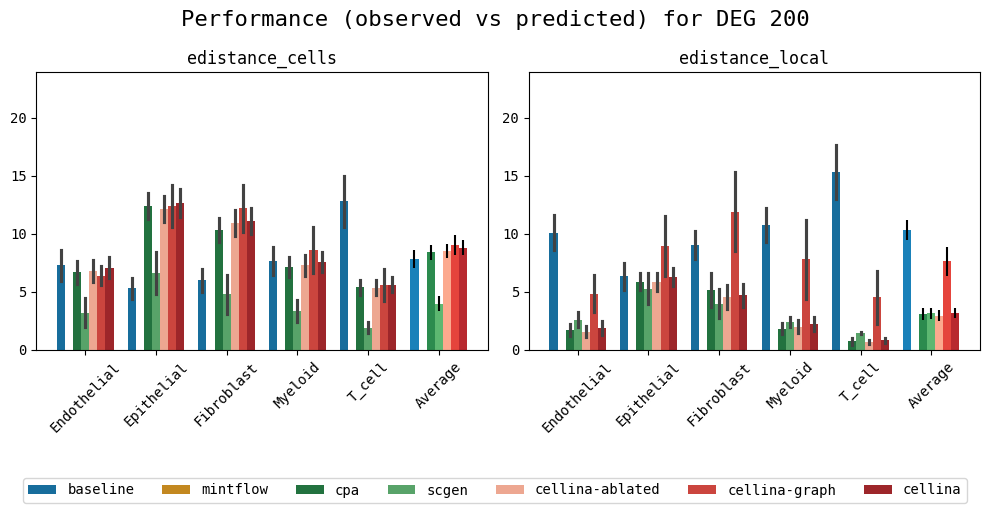

In [42]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=True,
    save_name="ood_summary_edist_200"
)

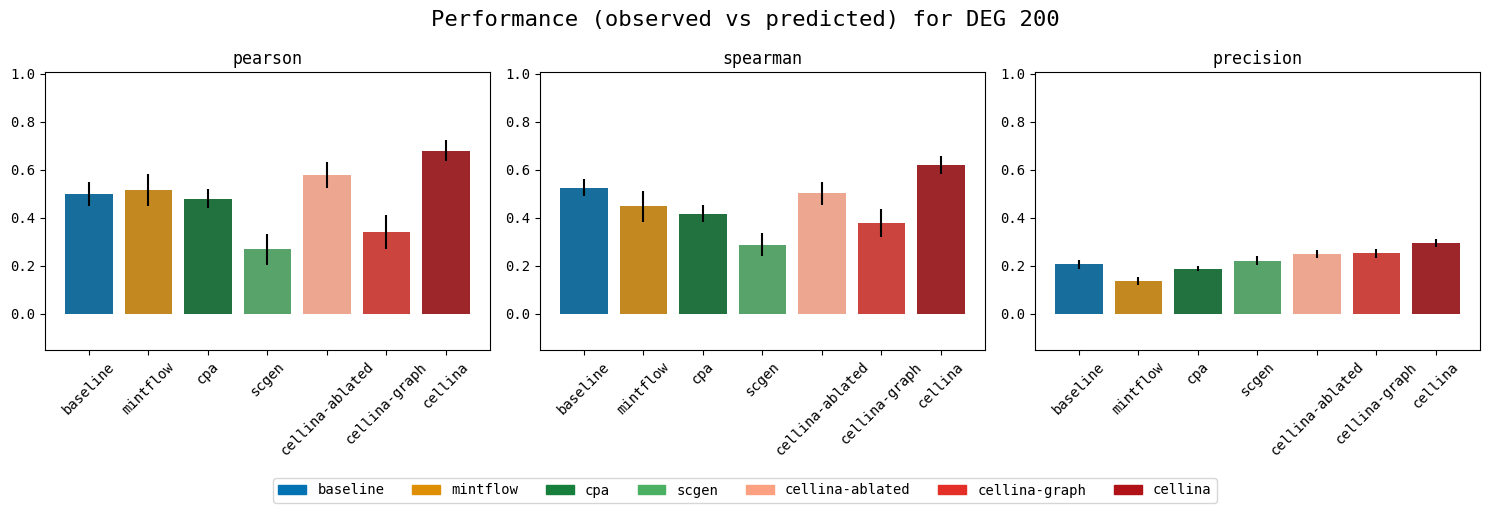

In [39]:
plot_model_comparison(
    df,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=True,
    save=True,
    save_name="ood_summary_correlations_200_average"
)

In [86]:
df.to_csv("../results/loo_summary_deg_200.csv", index=False)

# Testing some stuff

In [19]:
corr_dir = "/data2/a330d/datasets/crc/correlations"
pattern = os.path.join(corr_dir, "crc_*CRC*.json")
files = sorted(glob.glob(pattern))

rows = []
for fp in files:
    name = os.path.basename(fp)
    if not name.startswith("crc_") or not name.endswith(".json"):
        continue
    core = name[len("crc_"):-len(".json")]
    parts = core.split("_")
    if len(parts) < 3:
        # unexpected filename, skip
        continue
    sid = parts[0]
    model_name = parts[1]
    
    holdout_celltype = "_".join(parts[2:])
    try:
        with open(fp, "r") as f:
            data = json.load(f)
    except Exception:
        # skip unreadable/invalid json
        continue

    try:
        rows.append({
            "sid": sid,
            "model_name": model_name,
            "holdout_celltype": holdout_celltype,
            "n_deg": data.get("n_deg"),
            "spearman": data.get("spearman"),
            "pearson": data.get("pearson"),
            "precision": data.get("precision"),
            "direction_match": data.get("direction_match"),
            "direction_match_k": data.get("direction_match_k"),
            "mixing_index": data.get("mixing_index"),
            "edistance_global": data.get("edistance_global"),
            "edistance_local": data.get("edistance_local"),            
            "rmse": data.get("rmse"),
        })
    except Exception as e:
        print(f"Error processing file {fp}: {e}")
        continue

crc_corr_df = pd.DataFrame(rows)

In [20]:
# Remove -cf from the end of each model_name
crc_corr_df["model_name"] = crc_corr_df["model_name"].str.replace("-cf", "", regex=False)

In [58]:
crc_corr_df

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,120,baseline,Endothelial_CRC,200,0.503041,0.383371,0.170,0.970588,0.165,0.547060,23.927378,25.730283,13188.815073
1,120,baseline,Epithelial_CRC,200,0.129327,0.227521,0.415,0.578313,0.240,0.895650,22.045196,17.380554,546598.415842
2,120,baseline,Fibroblast_CRC,200,0.120677,0.202228,0.135,0.888889,0.120,0.605086,19.173983,21.201362,109470.811764
3,120,baseline,Myeloid_CRC,200,0.246870,0.323619,0.165,0.818182,0.135,0.502754,22.510635,24.561290,29706.071274
4,120,baseline,T_cell_CRC,200,0.676416,0.516258,0.255,0.862745,0.220,0.797638,29.482318,31.280952,14626.556810
...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,242,scgen,Endothelial_CRC,200,0.469705,0.719217,0.355,1.000000,0.355,0.806308,2.870100,2.680254,1228.225923
171,242,scgen,Epithelial_CRC,200,0.220968,0.090380,0.125,1.000000,0.125,0.260874,8.424536,7.485567,47921.777355
172,242,scgen,Fibroblast_CRC,200,0.332812,0.481801,0.320,1.000000,0.320,0.867351,3.905001,4.031436,18183.371912
173,242,scgen,Myeloid_CRC,200,0.315267,0.551632,0.370,0.986486,0.365,0.504493,2.668429,2.422061,2581.546006


In [68]:
df = crc_corr_df.copy() # start with existing dataframe

In [69]:
df["sid"] = df["sid"].astype(str)

In [70]:
# Combine with spatialprop results
spprop_csv_path = '../results/loo_spatialprop_crc.csv'
spprop_df = pd.read_csv(spprop_csv_path)
# Remove 'crc_' from sid in spprop_df
spprop_df["sid"] = spprop_df["sid"].str.replace("crc_", "", regex=False)
# Append 'target_domain' to 'holdout_celltype' in spprop_df to match with df
spprop_df["holdout_celltype"] = spprop_df["holdout_celltype"] + "_" + spprop_df["target_domain"]
spprop_df["sid"] = spprop_df["sid"].astype(str)

In [72]:
# Remove direction_match_k from df
#df = df.drop(columns=["direction_match_k"], errors="ignore")

In [73]:
common_cols = df.columns

spprop_df_trimmed = spprop_df[common_cols.intersection(spprop_df.columns)]

combined = pd.concat([df, spprop_df_trimmed], axis=0, ignore_index=True)
combined

,sid,model_name,holdout_celltype,n_deg,spearman,pearson,precision,direction_match,direction_match_k,mixing_index,edistance_global,edistance_local,rmse
0,120,baseline,Endothelial_CRC,200,0.503041,0.383371,0.170,0.970588,0.165,0.547060,23.927378,25.730283,13188.815073
1,120,baseline,Epithelial_CRC,200,0.129327,0.227521,0.415,0.578313,0.240,0.895650,22.045196,17.380554,546598.415842
2,120,baseline,Fibroblast_CRC,200,0.120677,0.202228,0.135,0.888889,0.120,0.605086,19.173983,21.201362,109470.811764
3,120,baseline,Myeloid_CRC,200,0.246870,0.323619,0.165,0.818182,0.135,0.502754,22.510635,24.561290,29706.071274
4,120,baseline,T_cell_CRC,200,0.676416,0.516258,0.255,0.862745,0.220,0.797638,29.482318,31.280952,14626.556810
...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,120,spatialprop,Endothelial_CRC,200,0.478182,0.506721,0.215,0.930233,NaN,0.812261,11.280195,15.936994,31552.996000
201,120,spatialprop,Epithelial_CRC,200,0.388226,0.386692,0.055,0.909091,NaN,0.779179,13.881730,15.240737,382983.620000
202,120,spatialprop,Fibroblast_CRC,200,0.155347,0.264726,0.175,0.771429,NaN,0.693359,7.035829,13.186207,153635.450000
203,120,spatialprop,Myeloid_CRC,200,0.504745,0.555167,0.150,0.966667,NaN,0.744805,13.856137,18.922516,77155.220000


In [74]:
metrics = ["pearson", "spearman", "precision", "direction_match", "direction_match_k", "mixing_index"]

In [75]:
grouping = "holdout_celltype"

# Define order
model_order = [
    "baseline",
    #"mintflow",
    "spatialprop",
    "cpa",
    "scgen",
    "cellina-ablated",
    #"cellina-mmd",
    "cellina-graph",
    "cellina",
]

default_palette = 'colorblind'
palette = default_palette

In [77]:
# Base palette (colorblind-friendly)
base_colors = sns.color_palette(default_palette, n_colors=len(model_order))

# Convert to dict mapped by model name
palette_dict = dict(zip(model_order, base_colors))

# Create a red gradient for the 3 cellina models
cellina_reds = sns.color_palette("Reds", 5)[1:] 

# skip the lightest so it's still visible
palette_dict["cellina-ablated"] = cellina_reds[0]
palette_dict["cellina-mmd"]     = cellina_reds[1]
palette_dict["cellina-graph"]   = cellina_reds[2]
palette_dict["cellina"]         = cellina_reds[3]

# non-spatial green
#palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
palette_dict["spatialprop"]   = sns.color_palette("Greens", 4)[0]

palette = palette_dict

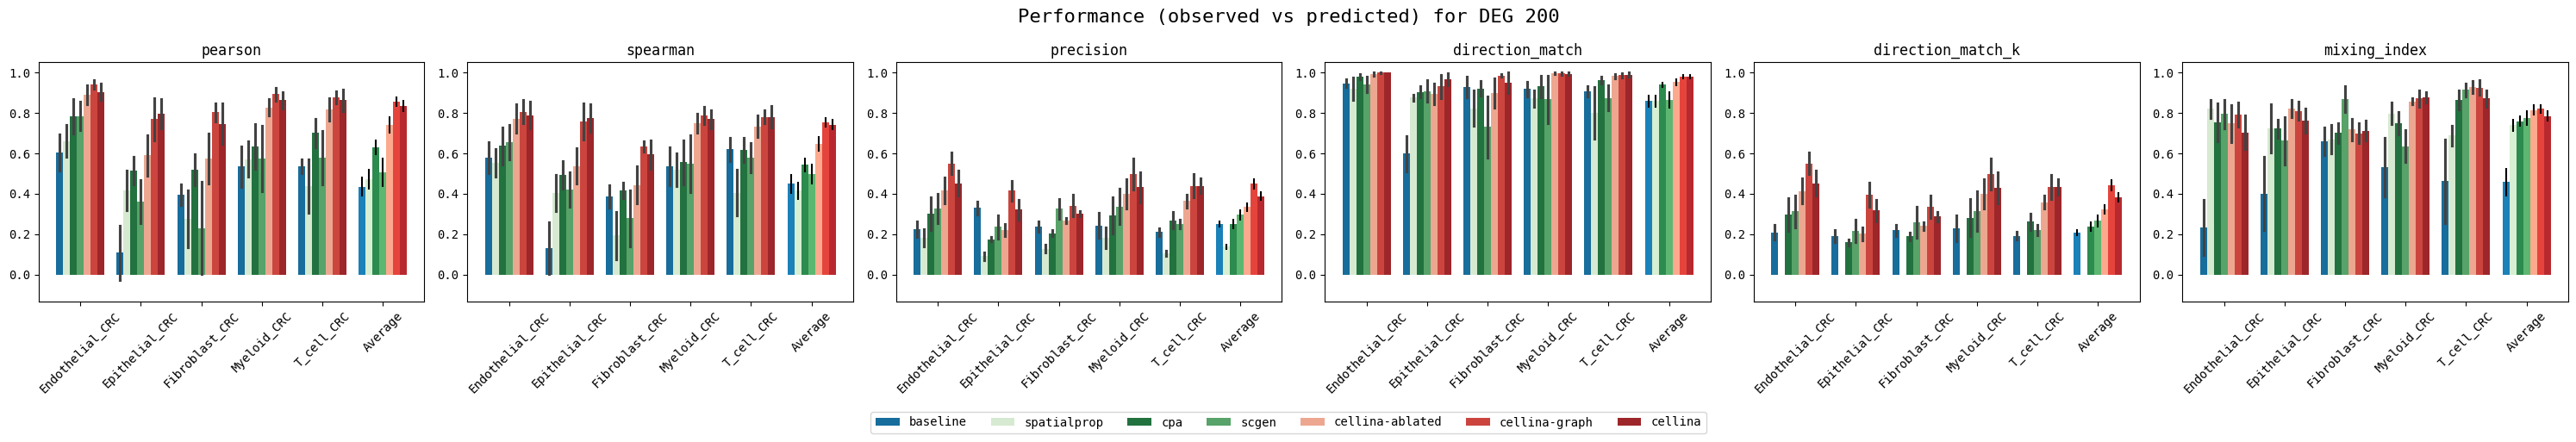

In [78]:
plot_model_comparison(
    combined,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [79]:
metrics = ["edistance_global", "edistance_local"]

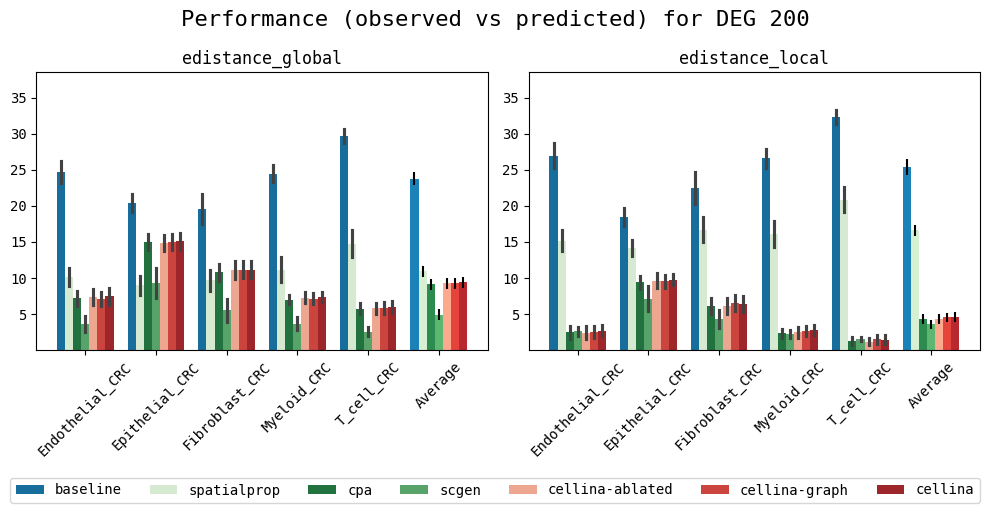

In [80]:
plot_model_comparison(
    combined,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [81]:
metrics = ["rmse"]

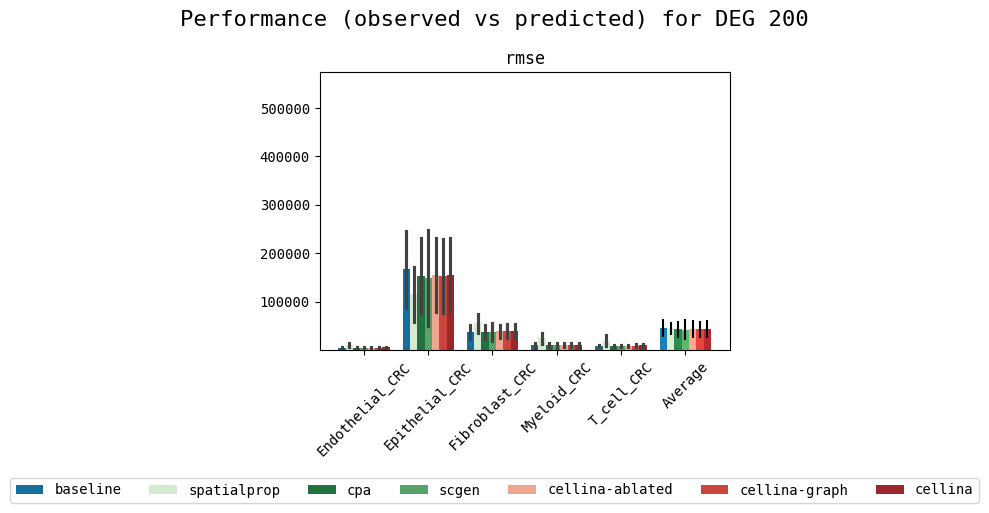

In [82]:
plot_model_comparison(
    combined,
    metrics,
    grouping,
    model_order,
    palette,
    average_only=False,
    save=False,
    save_name="ood_summary_correlations_200"
)

In [84]:
combined.to_csv("../results/loo_summary.csv", index=False)